# CLIP/SigLip Pytorch

This notebook replicates **CLIP** (Radford et al., 2021) and **SigLIP** (Zhai et al., 2023)
on the **Flickr8k** dataset, built for **Google Colab** (free T4 GPU is enough).




## 1. Setup

In [ ]:
!pip install -q datasets transformers timm --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 85.0 MB/s eta 0:00:00


In [ ]:
import os, math, time, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> T4 GPU")


device: cuda


## 2. Config

Everything that controls model size, training length, and data lives here.
Tweak this cell only the rest of the notebook reads from `CFG`.

In [ ]:
CFG = {
    # data
    "img_size": 128,
    "max_text_len": 40,
    "batch_size": 128,
    "val_fraction": 0.05,

    # model
    "embed_dim": 256,
    "proj_dim": 256,
    "img_patch_size": 16,
    "img_depth": 6,
    "img_heads": 8,
    "txt_depth": 4,
    "txt_heads": 8,
    "dropout": 0.1,

    # training
    "num_epochs": 8,          # bump this up once the pipeline is verified to work
    "lr": 3e-4,
    "weight_decay": 0.05,
    "warmup_steps": 200,

    # misc
    "tokenizer_name": "distilbert-base-uncased",  # tokenizer only — no pretrained weights used
    "checkpoint_dir": "/content/checkpoints",
    "save_to_drive": False,   # set True + run the drive-mount cell to persist checkpoints
    "drive_checkpoint_dir": "/content/drive/MyDrive/clip_siglip_project/checkpoints",
}

os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
CFG


{'img_size': 128,
 'max_text_len': 40,
 'batch_size': 128,
 'val_fraction': 0.05,
 'embed_dim': 256,
 'proj_dim': 256,
 'img_patch_size': 16,
 'img_depth': 6,
 'img_heads': 8,
 'txt_depth': 4,
 'txt_heads': 8,
 'dropout': 0.1,
 'num_epochs': 8,
 'lr': 0.0003,
 'weight_decay': 0.05,
 'warmup_steps': 200,
 'tokenizer_name': 'distilbert-base-uncased',
 'checkpoint_dir': '/content/checkpoints',
 'save_to_drive': False,
 'drive_checkpoint_dir': '/content/drive/MyDrive/clip_siglip_project/checkpoints'}

## 3. (Optional) Mount Google Drive

Run this if you want checkpoints and logs to survive a Colab disconnect.
Skip it if you're happy losing state when the runtime recycles.

In [ ]:
if CFG["save_to_drive"]:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(CFG["drive_checkpoint_dir"], exist_ok=True)
    print("Drive mounted. Checkpoints will also be copied to:", CFG["drive_checkpoint_dir"])
else:
    print("Skipping Drive mount (CFG['save_to_drive'] is False).")


## 4. Dataset — Flickr8k

Flickr8k has 8,000 images, each with 5 captions small enough to train fast on a single
GPU, large enough to show real zero-shot retrieval behavior.

We pull it from the Hugging Face Hub. If the primary source is unavailable, a fallback
and manual-download instructions are included below.

In [ ]:
from datasets import load_dataset

def load_flickr8k():
    # Primary source: a widely-used HF mirror of Flickr8k (image + 5 captions per row)
    candidates = ["jxie/flickr8k", "atasoglu/flickr8k-dataset"]
    last_err = None
    for name in candidates:
        try:
            print(f"Trying dataset: {name}")
            ds = load_dataset(name)
            print(f"Loaded '{name}' successfully.")
            return ds, name
        except Exception as e:
            print(f"  failed: {e}")
            last_err = e
    raise RuntimeError(
        "Could not load Flickr8k from any known HF mirror. "
        "Manual fallback: download from Kaggle "
        "(https://www.kaggle.com/datasets/adityajn105/flickr8k), upload to Colab or Drive, "
        "then adapt `Flickr8kDataset` below to read from the local `Images/` folder and "
        "`captions.txt`."
    ) from last_err

raw_ds, ds_name = load_flickr8k()
print(raw_ds)


Trying dataset: jxie/flickr8k


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00000-of-00002-2f8f6bfa852eac(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-2173151d8cd6c7(…): reconstructing file:   0%|          |  0.00B /  414MB            

...

data/test-00000-of-00001-42a2661d12c73e4(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loaded 'jxie/flickr8k' successfully.
DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


In [ ]:
# Normalize into a flat list of (PIL image, caption) pairs regardless of which
# mirror's schema we landed on.

def flatten_to_pairs(raw_ds, ds_name):
    pairs = []
    split = raw_ds["train"] if "train" in raw_ds else list(raw_ds.values())[0]
    cols = split.column_names
    img_col = "image" if "image" in cols else ("img" if "img" in cols else cols[0])
    # caption columns vary by mirror: either one 'caption' col with 5x rows,
    # or a 'captions' list col, or caption_0..caption_4 columns
    cap_list_col = next((c for c in cols if c in ("captions", "caption_list")), None)
    single_cap_col = next((c for c in cols if c == "caption"), None)
    numbered_cap_cols = [c for c in cols if c.lower().startswith("caption_")]

    for row in split:
        img = row[img_col]
        if cap_list_col is not None:
            caps = row[cap_list_col]
        elif numbered_cap_cols:
            caps = [row[c] for c in numbered_cap_cols if row[c]]
        elif single_cap_col is not None:
            caps = [row[single_cap_col]]
        else:
            continue
        for c in caps:
            if c:
                pairs.append((img, c.strip()))
    return pairs

pairs = flatten_to_pairs(raw_ds, ds_name)
print("total (image, caption) pairs:", len(pairs))
print("example caption:", pairs[0][1])


total (image, caption) pairs: 30000
example caption: A black dog is running after a white dog in the snow .


In [ ]:
# Train / val split (by pair, simple random split — fine for this scale)
random.shuffle(pairs)
n_val = max(1, int(len(pairs) * CFG["val_fraction"]))
val_pairs = pairs[:n_val]
train_pairs = pairs[n_val:]
print(f"train pairs: {len(train_pairs)} | val pairs: {len(val_pairs)}")


train pairs: 28500 | val pairs: 1500


## 5. Tokenizer, image transforms, and the Dataset/DataLoader

In [ ]:
from transformers import AutoTokenizer
from torchvision import transforms

tokenizer = AutoTokenizer.from_pretrained(CFG["tokenizer_name"])
PAD_ID = tokenizer.pad_token_id
VOCAB_SIZE = tokenizer.vocab_size
print("vocab size:", VOCAB_SIZE, "| pad id:", PAD_ID)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class Flickr8kDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img, caption = self.pairs[idx]
        img = img.convert("RGB")
        img = self.transform(img)
        tok = tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=CFG["max_text_len"],
            return_tensors="pt",
        )
        return img, tok["input_ids"].squeeze(0), caption


train_ds = Flickr8kDataset(train_pairs, train_transform)
val_ds = Flickr8kDataset(val_pairs, eval_transform)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                           num_workers=2, drop_last=True, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"train batches: {len(train_loader)} | val batches: {len(val_loader)}")
img, ids, cap = train_ds[0]
print("image shape:", img.shape, "| token ids shape:", ids.shape)
print("caption:", cap)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

vocab size: 30522 | pad id: 0
train batches: 222 | val batches: 12
image shape: torch.Size([3, 128, 128]) | token ids shape: torch.Size([40])
caption: The boy swings next to the barn .


## 6. Model — ViT image encoder + Transformer text encoder

Both encoders are implemented from scratch (no pretrained backbones) so the replication
is faithful to what CLIP/SigLIP actually are: two independently-trained encoders pulled
into a shared space by a contrastive objective. Only the *tokenizer* is reused from
`transformers`  that's just text splitting, not learned weights.

In [ ]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size, patch_size, in_chans, embed_dim):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, dim), nn.Dropout(dropout),
        )

    def forward(self, x, key_padding_mask=None):
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class ViTImageEncoder(nn.Module):
    """Vision Transformer (Dosovitskiy et al., 2020), trimmed down for this dataset scale."""
    def __init__(self, img_size, patch_size, embed_dim, depth, n_heads, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, 3, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, n_heads, dropout=dropout) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return x[:, 0]


class TextTransformerEncoder(nn.Module):
    """Small Transformer encoder over token ids, mean-pooled over non-pad tokens."""
    def __init__(self, vocab_size, max_len, embed_dim, depth, n_heads, dropout=0.1, pad_token_id=0):
        super().__init__()
        self.pad_token_id = pad_token_id
        self.token_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_token_id)
        self.pos_embed = nn.Parameter(torch.zeros(1, max_len, embed_dim))
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, n_heads, dropout=dropout) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, input_ids):
        B, L = input_ids.shape
        key_padding_mask = input_ids.eq(self.pad_token_id)
        x = self.token_embed(input_ids) + self.pos_embed[:, :L]
        for blk in self.blocks:
            x = blk(x, key_padding_mask=key_padding_mask)
        x = self.norm(x)
        mask = (~key_padding_mask).unsqueeze(-1).float()
        pooled = (x * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        return pooled


class ProjectionHead(nn.Module):
    """Maps an encoder's pooled output into the shared, L2-normalized embedding space."""
    def __init__(self, in_dim, proj_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, proj_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(proj_dim, proj_dim),
        )

    def forward(self, x):
        x = self.net(x)
        return F.normalize(x, dim=-1)


class DualEncoderModel(nn.Module):
    """The shared architecture behind both CLIP and SigLIP — they differ only in the loss."""
    def __init__(self, cfg, vocab_size, pad_token_id):
        super().__init__()
        self.image_encoder = ViTImageEncoder(
            cfg["img_size"], cfg["img_patch_size"], cfg["embed_dim"],
            cfg["img_depth"], cfg["img_heads"], cfg["dropout"],
        )
        self.text_encoder = TextTransformerEncoder(
            vocab_size, cfg["max_text_len"], cfg["embed_dim"],
            cfg["txt_depth"], cfg["txt_heads"], cfg["dropout"], pad_token_id,
        )
        self.image_proj = ProjectionHead(cfg["embed_dim"], cfg["proj_dim"], cfg["dropout"])
        self.text_proj = ProjectionHead(cfg["embed_dim"], cfg["proj_dim"], cfg["dropout"])
        # learnable temperature (both CLIP and SigLIP); learnable bias (SigLIP only, unused by CLIP)
        self.logit_scale = nn.Parameter(torch.ones([]) * math.log(1 / 0.07))
        self.logit_bias = nn.Parameter(torch.zeros([]))

    def encode_image(self, images):
        return self.image_proj(self.image_encoder(images))

    def encode_text(self, input_ids):
        return self.text_proj(self.text_encoder(input_ids))

    def forward(self, images, input_ids):
        return self.encode_image(images), self.encode_text(input_ids)


def count_params(model):
    return sum(p.numel() for p in model.parameters()) / 1e6

_test_model = DualEncoderModel(CFG, VOCAB_SIZE, PAD_ID)
print(f"model params: {count_params(_test_model):.2f}M")
del _test_model


model params: 16.20M


## 7. Losses — CLIP (softmax InfoNCE) vs SigLIP (sigmoid)

**CLIP loss**: treats retrieval as an N-way classification problem over the batch for
each image, the matching caption is the "correct class" among all captions in the batch,
and vice versa. Needs a reasonably large batch to have enough negatives.

**SigLIP loss**: treats every image-caption pair independently as a binary
match/no-match decision (sigmoid, not softmax). This removes the need for a global
normalization over the batch, so it's more stable at small batch sizes relevant for us
since Colab GPU memory caps how large `batch_size` can realistically get.

In [ ]:
def clip_loss(image_embeds, text_embeds, logit_scale):
    scale = logit_scale.exp()
    logits = scale * image_embeds @ text_embeds.t()
    labels = torch.arange(logits.shape[0], device=logits.device)
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.t(), labels)
    return (loss_i + loss_t) / 2


def siglip_loss(image_embeds, text_embeds, logit_scale, logit_bias):
    n = image_embeds.shape[0]
    scale = logit_scale.exp()
    logits = scale * image_embeds @ text_embeds.t() + logit_bias
    labels = 2 * torch.eye(n, device=logits.device) - 1  # +1 diagonal (match), -1 off-diagonal
    loss = -F.logsigmoid(labels * logits).sum() / n
    return loss


## 8. Training loop

In [ ]:
def get_lr_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


@torch.no_grad()
def evaluate_loss(model, loader, loss_name):
    model.eval()
    total, n_batches = 0.0, 0
    for images, input_ids, _ in loader:
        images, input_ids = images.to(DEVICE), input_ids.to(DEVICE)
        img_e, txt_e = model(images, input_ids)
        if loss_name == "clip":
            loss = clip_loss(img_e, txt_e, model.logit_scale)
        else:
            loss = siglip_loss(img_e, txt_e, model.logit_scale, model.logit_bias)
        total += loss.item()
        n_batches += 1
    model.train()
    return total / max(1, n_batches)


def train_model(loss_name, cfg, tag):
    """loss_name: 'clip' or 'siglip'. tag: used for checkpoint filenames/logging."""
    assert loss_name in ("clip", "siglip")
    model = DualEncoderModel(cfg, VOCAB_SIZE, PAD_ID).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    total_steps = len(train_loader) * cfg["num_epochs"]
    scheduler = get_lr_scheduler(optimizer, cfg["warmup_steps"], total_steps)

    history = {"train_loss": [], "val_loss": [], "step": []}
    step = 0
    t0 = time.time()

    for epoch in range(cfg["num_epochs"]):
        running = 0.0
        for images, input_ids, _ in train_loader:
            images, input_ids = images.to(DEVICE), input_ids.to(DEVICE)
            img_e, txt_e = model(images, input_ids)
            if loss_name == "clip":
                loss = clip_loss(img_e, txt_e, model.logit_scale)
            else:
                loss = siglip_loss(img_e, txt_e, model.logit_scale, model.logit_bias)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            running += loss.item()
            step += 1
            if step % 50 == 0:
                print(f"[{tag}] epoch {epoch+1}/{cfg['num_epochs']} step {step}/{total_steps} "
                      f"loss {loss.item():.4f} lr {scheduler.get_last_lr()[0]:.2e} "
                      f"elapsed {time.time()-t0:.0f}s")

        train_epoch_loss = running / len(train_loader)
        val_epoch_loss = evaluate_loss(model, val_loader, loss_name)
        history["train_loss"].append(train_epoch_loss)
        history["val_loss"].append(val_epoch_loss)
        history["step"].append(step)
        print(f"== [{tag}] epoch {epoch+1} done | train {train_epoch_loss:.4f} | val {val_epoch_loss:.4f} ==")

        ckpt_path = os.path.join(cfg["checkpoint_dir"], f"{tag}_epoch{epoch+1}.pt")
        torch.save({"model": model.state_dict(), "cfg": cfg, "epoch": epoch + 1}, ckpt_path)
        if cfg["save_to_drive"]:
            drive_path = os.path.join(cfg["drive_checkpoint_dir"], f"{tag}_epoch{epoch+1}.pt")
            torch.save({"model": model.state_dict(), "cfg": cfg, "epoch": epoch + 1}, drive_path)

    return model, history


## 9. Train CLIP

In [ ]:
clip_model, clip_history = train_model("clip", CFG, tag="clip")


[clip] epoch 1/8 step 50/1776 loss 4.7729 lr 7.50e-05 elapsed 17s
[clip] epoch 1/8 step 100/1776 loss 4.6902 lr 1.50e-04 elapsed 32s
[clip] epoch 1/8 step 150/1776 loss 4.4882 lr 2.25e-04 elapsed 48s
[clip] epoch 1/8 step 200/1776 loss 4.3962 lr 3.00e-04 elapsed 63s
== [clip] epoch 1 done | train 4.6354 | val 4.3624 ==
[clip] epoch 2/8 step 250/1776 loss 4.1790 lr 2.99e-04 elapsed 82s
[clip] epoch 2/8 step 300/1776 loss 4.2922 lr 2.97e-04 elapsed 97s
[clip] epoch 2/8 step 350/1776 loss 4.2431 lr 2.93e-04 elapsed 112s
[clip] epoch 2/8 step 400/1776 loss 4.0004 lr 2.88e-04 elapsed 126s
== [clip] epoch 2 done | train 4.2018 | val 4.0062 ==
[clip] epoch 3/8 step 450/1776 loss 3.7837 lr 2.82e-04 elapsed 147s
[clip] epoch 3/8 step 500/1776 loss 3.8665 lr 2.74e-04 elapsed 161s
[clip] epoch 3/8 step 550/1776 loss 3.9863 lr 2.65e-04 elapsed 176s
[clip] epoch 3/8 step 600/1776 loss 3.6335 lr 2.55e-04 elapsed 191s
[clip] epoch 3/8 step 650/1776 loss 3.8956 lr 2.44e-04 elapsed 206s
== [clip] epoch

## 10. Zero-shot retrieval evaluation

We embed the full validation set once, then for each query measure Recall@1/5/10
the standard metric CLIP's paper reports for retrieval.

In [ ]:
@torch.no_grad()
def embed_val_set(model, loader):
    model.eval()
    all_img, all_txt, all_caps = [], [], []
    for images, input_ids, caps in loader:
        images, input_ids = images.to(DEVICE), input_ids.to(DEVICE)
        img_e, txt_e = model(images, input_ids)
        all_img.append(img_e.cpu())
        all_txt.append(txt_e.cpu())
        all_caps.extend(caps)
    model.train()
    return torch.cat(all_img), torch.cat(all_txt), all_caps


def recall_at_k(sim_matrix, ks=(1, 5, 10)):
    """sim_matrix[i, j] = similarity of query i to candidate j.
    Assumes the correct match for query i is candidate i (aligned val set)."""
    n = sim_matrix.shape[0]
    ranks = sim_matrix.argsort(dim=1, descending=True)
    target = torch.arange(n).unsqueeze(1)
    correct_rank = (ranks == target).float().argmax(dim=1)
    return {f"R@{k}": (correct_rank < k).float().mean().item() * 100 for k in ks}


def zero_shot_retrieval_report(model, loader, tag):
    img_e, txt_e, caps = embed_val_set(model, loader)
    sim = img_e @ txt_e.t()
    t2i = recall_at_k(sim.t())   # text  -> image
    i2t = recall_at_k(sim)       # image -> text
    print(f"[{tag}] text->image retrieval:", t2i)
    print(f"[{tag}] image->text retrieval:", i2t)
    return {"text_to_image": t2i, "image_to_text": i2t}, img_e, txt_e, caps


In [ ]:
clip_metrics, clip_img_e, clip_txt_e, val_caps = zero_shot_retrieval_report(clip_model, val_loader, "clip")


[clip] text->image retrieval: {'R@1': 4.800000041723251, 'R@5': 17.666666209697723, 'R@10': 26.533332467079163}
[clip] image->text retrieval: {'R@1': 5.666666850447655, 'R@5': 16.66666716337204, 'R@10': 26.866665482521057}


### Qualitative check: text query → top retrieved images

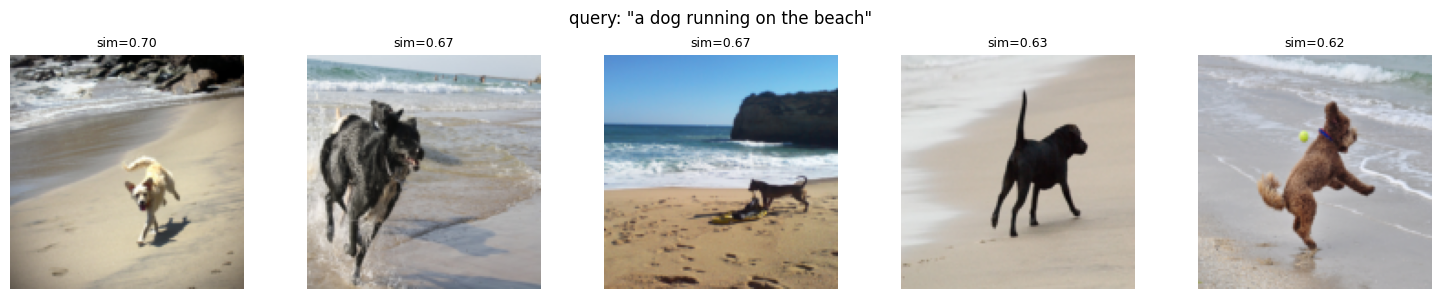

In [ ]:
@torch.no_grad()
def show_text_to_image_retrieval(model, val_ds, query, k=5):
    model.eval()
    tok = tokenizer(query, padding="max_length", truncation=True,
                     max_length=CFG["max_text_len"], return_tensors="pt").to(DEVICE)
    txt_e = model.encode_text(tok["input_ids"])

    imgs, sims = [], []
    for i in range(len(val_ds)):
        img, _, _ = val_ds[i]
        imgs.append(img)
    imgs_tensor = torch.stack(imgs).to(DEVICE)

    img_e = model.encode_image(imgs_tensor)
    sim = (txt_e @ img_e.t()).squeeze(0)
    top_idx = sim.topk(k).indices.cpu().tolist()

    fig, axes = plt.subplots(1, k, figsize=(3 * k, 3))
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    for ax, idx in zip(axes, top_idx):
        img = imgs[idx] * std + mean
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
        ax.set_title(f"sim={sim[idx].item():.2f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f'query: "{query}"')
    plt.tight_layout()
    plt.show()
    model.train()

# Try a few queries of your own here
show_text_to_image_retrieval(clip_model, val_ds, "a dog running on the beach")


## 11. Train SigLIP

Same architecture, same data, only the loss function changes.

In [ ]:
siglip_model, siglip_history = train_model("siglip", CFG, tag="siglip")


[siglip] epoch 1/8 step 50/1776 loss 5.7989 lr 7.50e-05 elapsed 16s
[siglip] epoch 1/8 step 100/1776 loss 5.7435 lr 1.50e-04 elapsed 31s
[siglip] epoch 1/8 step 150/1776 loss 5.5616 lr 2.25e-04 elapsed 46s
[siglip] epoch 1/8 step 200/1776 loss 5.6139 lr 3.00e-04 elapsed 61s
== [siglip] epoch 1 done | train 8.1888 | val 5.4970 ==
[siglip] epoch 2/8 step 250/1776 loss 5.4679 lr 2.99e-04 elapsed 89s
[siglip] epoch 2/8 step 300/1776 loss 5.4291 lr 2.97e-04 elapsed 105s
[siglip] epoch 2/8 step 350/1776 loss 5.2968 lr 2.93e-04 elapsed 120s
[siglip] epoch 2/8 step 400/1776 loss 5.2515 lr 2.88e-04 elapsed 135s
== [siglip] epoch 2 done | train 5.3061 | val 5.1459 ==
[siglip] epoch 3/8 step 450/1776 loss 5.0618 lr 2.82e-04 elapsed 154s
[siglip] epoch 3/8 step 500/1776 loss 4.9343 lr 2.74e-04 elapsed 170s
[siglip] epoch 3/8 step 550/1776 loss 5.1375 lr 2.65e-04 elapsed 185s
[siglip] epoch 3/8 step 600/1776 loss 4.9806 lr 2.55e-04 elapsed 200s
[siglip] epoch 3/8 step 650/1776 loss 4.9065 lr 2.44e-

In [ ]:
siglip_metrics, siglip_img_e, siglip_txt_e, _ = zero_shot_retrieval_report(siglip_model, val_loader, "siglip")


[siglip] text->image retrieval: {'R@1': 3.5333331674337387, 'R@5': 14.133332669734955, 'R@10': 21.99999988079071}
[siglip] image->text retrieval: {'R@1': 3.400000184774399, 'R@5': 13.066667318344116, 'R@10': 20.866666734218597}


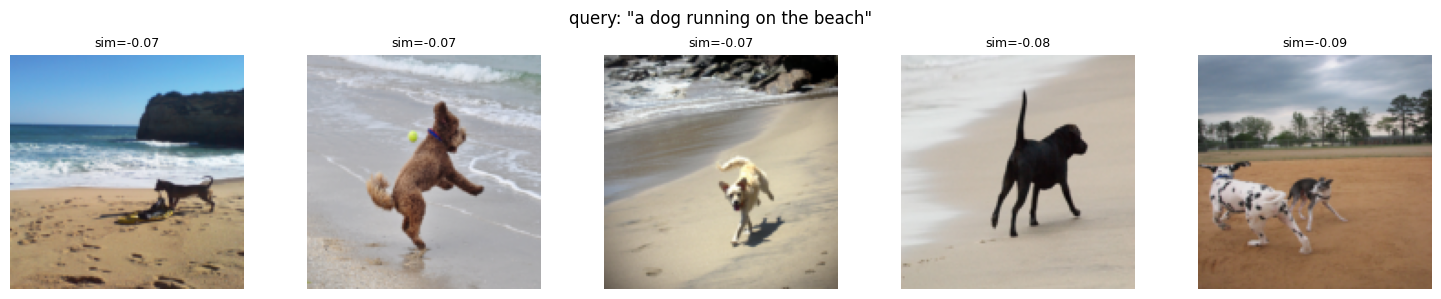

In [ ]:
show_text_to_image_retrieval(siglip_model, val_ds, "a dog running on the beach")


## 12. CLIP vs SigLIP — comparison

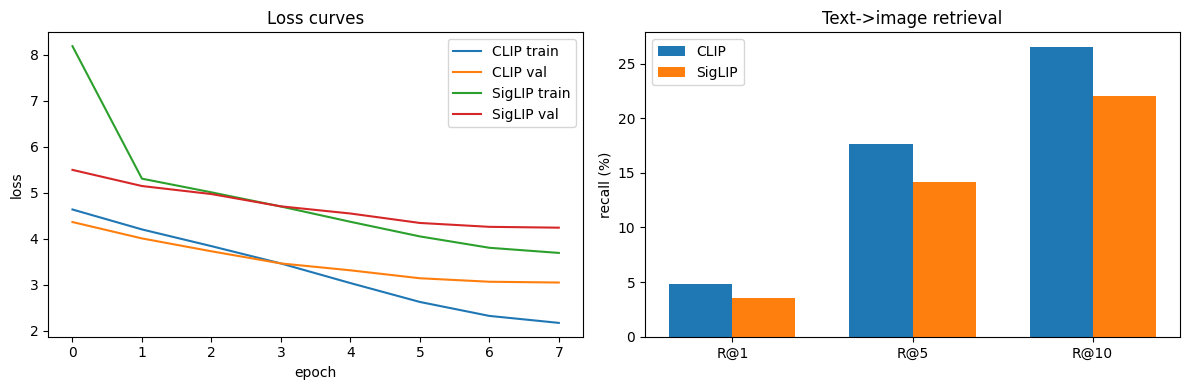


Summary table (text -> image retrieval):
metric        CLIP    SigLIP
R@1           4.80      3.53
R@5          17.67     14.13
R@10         26.53     22.00


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(clip_history["train_loss"], label="CLIP train")
axes[0].plot(clip_history["val_loss"], label="CLIP val")
axes[0].plot(siglip_history["train_loss"], label="SigLIP train")
axes[0].plot(siglip_history["val_loss"], label="SigLIP val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss curves")
axes[0].legend()

import numpy as np
labels = ["R@1", "R@5", "R@10"]
x = np.arange(len(labels))
width = 0.35
clip_vals = [clip_metrics["text_to_image"][l] for l in labels]
siglip_vals = [siglip_metrics["text_to_image"][l] for l in labels]
axes[1].bar(x - width/2, clip_vals, width, label="CLIP")
axes[1].bar(x + width/2, siglip_vals, width, label="SigLIP")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel("recall (%)"); axes[1].set_title("Text->image retrieval")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG["checkpoint_dir"], "clip_vs_siglip_comparison.png"), dpi=150)
plt.show()

print("\nSummary table (text -> image retrieval):")
print(f"{'metric':<8}{'CLIP':>10}{'SigLIP':>10}")
for l in labels:
    print(f"{l:<8}{clip_metrics['text_to_image'][l]:>10.2f}{siglip_metrics['text_to_image'][l]:>10.2f}")


## 13. Save everything + notes for the README

Checkpoints already saved per-epoch to `CFG['checkpoint_dir']` (and Drive, if enabled).
This cell dumps final metrics/history to JSON so you can pull numbers straight into your
project README without re-running training.

In [ ]:
results = {
    "clip": {"history": clip_history, "metrics": clip_metrics},
    "siglip": {"history": siglip_history, "metrics": siglip_metrics},
    "config": CFG,
    "dataset_source": ds_name,
    "num_train_pairs": len(train_pairs),
    "num_val_pairs": len(val_pairs),
}
results_path = os.path.join(CFG["checkpoint_dir"], "results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print("Saved results to", results_path)

if CFG["save_to_drive"]:
    import shutil
    shutil.copy(results_path, CFG["drive_checkpoint_dir"])
    print("Also copied to Drive.")


Saved results to /content/checkpoints/results.json
